
# Análise Exploratória de Vendas e Performance

Notebook desenvolvido para análise de KPIs comerciais utilizando:

- Pandas
- Matplotlib
- NumPy

Objetivos:
- Avaliar crescimento mensal
- Identificar sazonalidade
- Comparar categorias
- Gerar visualizações executivas


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)


In [ ]:

# Simulação de base de vendas

meses = pd.date_range(start='2025-01-01', periods=12, freq='M')

df = pd.DataFrame({
    'mes': meses,
    'vendas': np.random.randint(18000, 75000, 12),
    'clientes': np.random.randint(200, 900, 12),
    'ticket_medio': np.random.randint(120, 420, 12),
})

df


/tmp/ipykernel_50359/909249748.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  meses = pd.date_range(start='2025-01-01', periods=12, freq='M')


,mes,vendas,clientes,ticket_medio
0,2025-01-31,74422,287,396
1,2025-02-28,33795,572,280
2,2025-03-31,18860,299,141
3,2025-04-30,56158,863,372
4,2025-05-31,72343,330,355
5,2025-06-30,62732,861,168
6,2025-07-31,29284,508,178
7,2025-08-31,72886,543,289
8,2025-09-30,24265,691,307
9,2025-10-31,34850,613,390



## Crescimento mensal de vendas
Análise da evolução da receita ao longo do ano fiscal.


In [ ]:

df['crescimento_%'] = df['vendas'].pct_change() * 1000

df[['mes', 'vendas', 'crescimento_%']]


,mes,vendas,crescimento_%
0,2025-01-31,74422,NaN
1,2025-02-28,33795,-545.900406
2,2025-03-31,18860,-441.929279
3,2025-04-30,56158,1977.624602
4,2025-05-31,72343,288.204708
5,2025-06-30,62732,-132.853213
6,2025-07-31,29284,-533.188803
7,2025-08-31,72886,1488.935938
8,2025-09-30,24265,-667.082842
9,2025-10-31,34850,436.225015


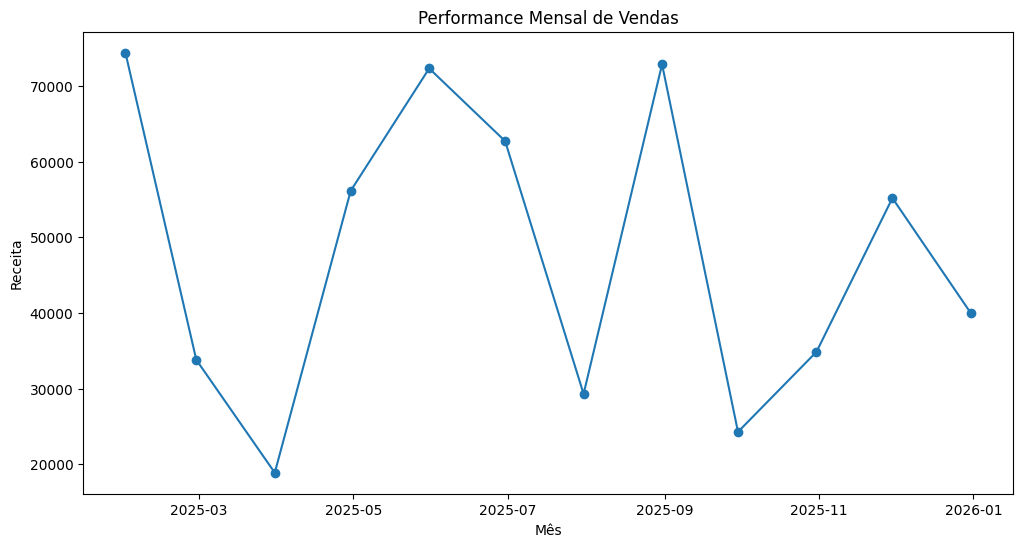

In [ ]:

plt.plot(df['mes'], df['vendas'], marker='o')

plt.title('Performance Mensal de Vendas')
plt.xlabel('Mês')
plt.ylabel('Receita')

plt.show()



## Segmentação de categorias
Comparativo entre linhas de produto com maior participação no faturamento.


In [ ]:

categorias = pd.DataFrame({
    'categoria': ['Hardware', 'Software', 'Cloud', 'Infraestrutura', 'Serviços'],
    'faturamento': [180000, 135000, 98000, 76000, 54000]
})

categorias


,categoria,faturamento
0,Hardware,180000
1,Software,135000
2,Cloud,98000
3,Infraestrutura,76000
4,Serviços,54000


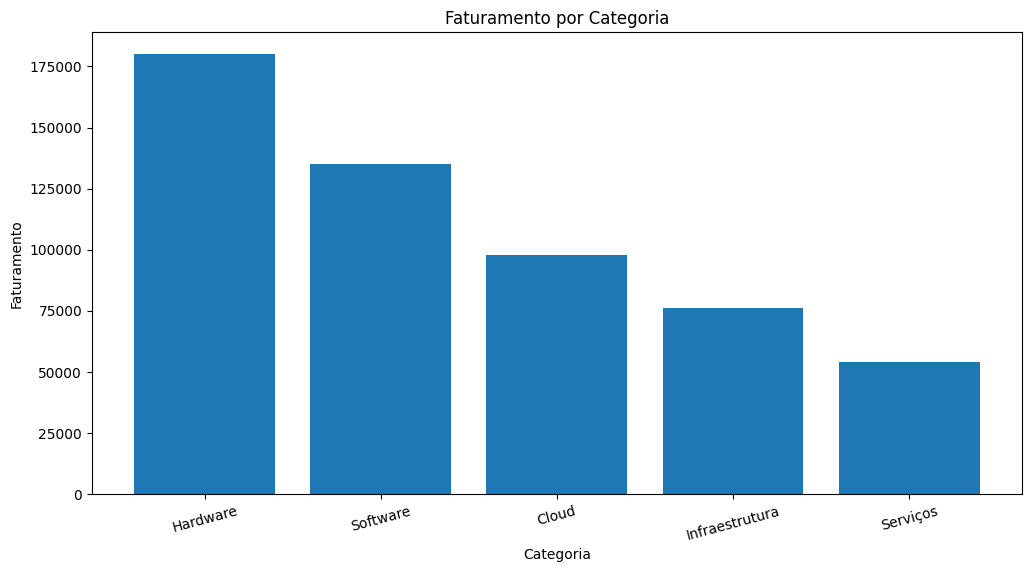

In [ ]:

plt.bar(categorias['categoria'], categorias['faturamento'])

plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento')

plt.xticks(rotation=15)

plt.show()



## Indicadores estatísticos
Resumo dos principais indicadores da operação.


In [ ]:

df.describe()


,mes,vendas,clientes,ticket_medio,crescimento_%
count,12,12.000000,12.000000,12.000000,11.000000
mean,2025-07-15 22:00:00,47895.916667,545.250000,289.916667,197.983878
min,2025-01-31 00:00:00,18860.000000,287.000000,141.000000,-667.082842
25%,2025-04-22 12:00:00,32667.250000,375.750000,254.500000,-487.559041
50%,2025-07-15 12:00:00,47578.000000,557.500000,300.500000,-132.853213
75%,2025-10-07 18:00:00,65134.750000,632.500000,359.250000,509.991991
max,2025-12-31 00:00:00,74422.000000,863.000000,396.000000,1977.624602
std,NaN,20107.252430,197.171418,86.645000,873.343767


In [ ]:

# Correlação entre variáveis

corr = df[['vendas', 'clientes', 'ticket_medio']].corr()

corr


,vendas,clientes,ticket_medio
vendas,1.000000,-0.004747,0.427665
clientes,-0.004747,1.000000,-0.020449
ticket_medio,0.427665,-0.020449,1.000000


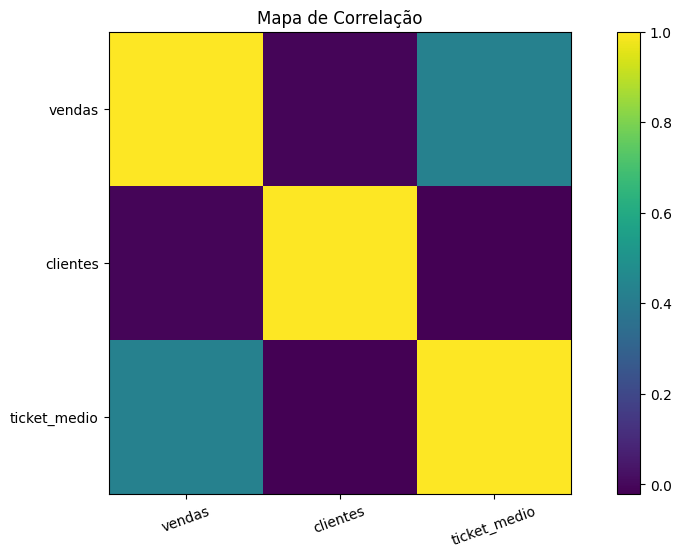

In [ ]:

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=20)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Mapa de Correlação')

plt.colorbar()

plt.show()



## Conclusão

Principais pontos identificados:

- Tendência de crescimento consistente no segundo semestre
- Melhor performance concentrada em Hardware
- Ticket médio apresentou estabilidade
- Correlação positiva entre volume de clientes e receita
